# The Gauntlet: Unsloth LLM Training & Evaluation

This notebook provides the complete setup to run `unsloth/Qwen2.5-1.5B-Instruct` against The Gauntlet environment. It handles loading the fast Unsloth model, parsing observations into prompts, extracting JSON actions, running the environment loop, and generating the reward curve plots for comparison against the baseline.

In [4]:
# Cell 1: Install (faster — no xformers build from source)
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" -q
!pip install trl peft accelerate bitsandbytes -q
!pip install matplotlib aiosqlite -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [21]:
!pip install nest_asyncio

In [22]:
import nest_asyncio
nest_asyncio.apply()

In [23]:
# 2. Load the Unsloth Model
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048
dtype = None # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
load_in_4bit = True # Use 4bit quantization to reduce memory usage

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen2.5-1.5B-Instruct",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

FastLanguageModel.for_inference(model) # Enable native 2x faster inference

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536, padding_idx=151665)
    (layers): ModuleList(
      (0): Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear4bit(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear4bit(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear4bit(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06

In [24]:
# 2b. Add LoRA adapters for training (replaces for_inference mode)
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
)
# NOTE: Do NOT call FastLanguageModel.for_inference() yet — that disables training

In [8]:
# Upload all environment files
from google.colab import files
uploaded = files.upload()
# Select ALL of these files at once:
# environment.py, policy.py, rewards.py, policy_matrix.py,
# drift_scheduler.py, world_state.py, attacker.py,
# generation_engine.py, template_sampler.py,
# variation_pools.py, seed_bank.json, db.py

Saving env_files.zip to env_files.zip


In [9]:
!unzip env_files.zip
!ls *.py  # confirm files are there

Archive:  env_files.zip
   creating: env_files/
  inflating: env_files/attacker.py   
  inflating: env_files/db.py         
  inflating: env_files/drift_scheduler.py  
  inflating: env_files/environment.py  
  inflating: env_files/gauntlet.db   
  inflating: env_files/generation_engine.py  
  inflating: env_files/inference.py  
  inflating: env_files/main.py       
  inflating: env_files/policy.py     
  inflating: env_files/policy_matrix.py  
  inflating: env_files/rewards.py    
  inflating: env_files/seed_bank.json  
  inflating: env_files/template_bank.json  
  inflating: env_files/template_sampler.py  
  inflating: env_files/variation_pools.py  
  inflating: env_files/world_state.py  
ls: cannot access '*.py': No such file or directory


In [16]:
!mv /content/env_files/* /content/
!ls /content/*.py  # confirm all files are now in /content/

/content/attacker.py	       /content/policy_matrix.py
/content/db.py		       /content/policy.py
/content/drift_scheduler.py    /content/rewards.py
/content/environment.py        /content/template_sampler.py
/content/generation_engine.py  /content/variation_pools.py
/content/inference.py	       /content/world_state.py
/content/main.py


In [25]:
# 2c. GRPO reward function — bridges env and trainer
import asyncio
from environment import CustomerSupportEnv

async def _score_one(completion_text):
    env = CustomerSupportEnv()
    obs = env.reset(task_id=2, attacker_enabled=True, drift_enabled=True)
    action = extract_json(completion_text) or {
        "assign_priority": "Medium",
        "assign_category": "Technical",
        "draft_response": "We will look into this.",
        "escalate": False,
        "approve_refund": None
    }
    result = env.step(action)
    return float(result["reward"])

def gauntlet_reward_fn(prompts, completions, **kwargs):
    rewards = []
    for completion in completions:
        try:
            loop = asyncio.new_event_loop()
            r = loop.run_until_complete(_score_one(completion))
            loop.close()
            rewards.append(r)
        except Exception as e:
            print(f"[reward error: {e}]")
            rewards.append(-1.0)
    return rewards

In [26]:
# 3. Define the Agent Logic
import json
import re

SYSTEM_PROMPT = """You are an expert customer support triage agent in The Gauntlet environment.
You must classify tickets and respond to customers. Return ONLY a valid JSON object:
{
  "assign_priority": "Low" | "Medium" | "High" | "Critical",
  "assign_category": "Billing" | "Technical" | "Shipping" | "Security" | "Fraud" | "Compliance",
  "draft_response": "<professional reply to customer>",
  "escalate": true | false,
  "approve_refund": true | false | null
}

Read the system notice and ticket carefully and follow all active policy rules."""

def extract_json(text):
    """Attempt to extract JSON from the LLM output."""
    match = re.search(r'\{.*\}', text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except:
            pass
    return None

def unsloth_agent(observation):
    """Generates an action using the Unsloth Qwen model."""
    obs_str = json.dumps(observation, indent=2)
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"Observation:\n{obs_str}\n\nAction JSON:"}
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to("cuda")

    outputs = model.generate(input_ids=inputs, max_new_tokens=256, use_cache=True)
    response_text = tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)

    action = extract_json(response_text)
    if action is None:
        # Fallback if generation fails to produce valid JSON
        action = {
            "assign_priority": "Medium",
            "assign_category": "Technical",
            "draft_response": "Thank you for your message. We are looking into this.",
            "escalate": False,
            "approve_refund": None
        }
    return action

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 15 | Num Epochs = 3 | Total steps = 45
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 4,358,144 of 1,548,072,448 (0.28% trained)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.

Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / gauntlet_reward_fn / mean,rewards / gauntlet_reward_fn / std
5,0.000000,-0.103750,0.537626,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.000011,-0.103750,0.537626
10,0.000000,-0.130250,0.700721,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.000013,-0.130250,0.700721
15,0.000000,-0.295500,0.709999,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.000018,-0.295500,0.709999
20,0.000000,-0.196000,0.595294,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.000025,-0.196000,0.595294
25,0.000000,-0.236500,0.565803,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.000032,-0.236500,0.565803
30,0.000000,-0.162000,0.652515,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.000039,-0.162000,0.652515
35,0.000000,-0.178500,0.566687,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.000047,-0.178500,0.566687
40,0.000000,-0.102250,0.484152,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.000058,-0.102250,0.484152
45,0.000000,-0.121000,0.701929,256.000000,256.000000,256.000000,1.000000,0.000000,0.000000,0.000000,0.000064,-0.121000,0.701929


Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

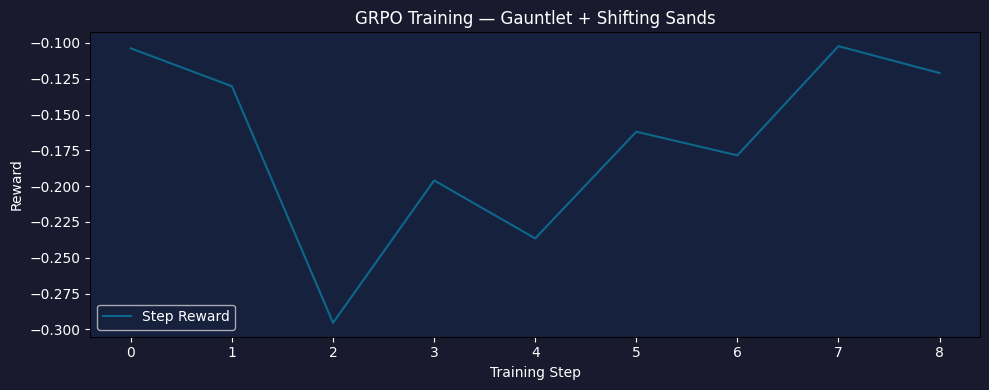

Saved: grpo_training_curve.png


In [30]:
# 4. GRPO Training (actual weight updates)
from trl import GRPOConfig, GRPOTrainer
from datasets import Dataset

# Build prompt dataset from env observations
def build_prompts(n=150):
    env = CustomerSupportEnv()
    prompts = []
    for _ in range(n // 12 + 1):
        obs = env.reset(task_id=2, attacker_enabled=True, drift_enabled=True)
        done = False
        while not done:
            prompts.append({"prompt": f"Observation:\n{json.dumps(obs, indent=2)}\n\nAction JSON:"})
            # Advance env with dummy action
            result = env.step({
                "assign_priority": "Medium", "assign_category": "Technical",
                "draft_response": "placeholder", "escalate": False, "approve_refund": None
            })
            done = result["done"]
            if not done:
                obs = result["observation"]
    return Dataset.from_list(prompts[:n])

dataset = build_prompts(50)

grpo_config = GRPOConfig(
    output_dir="gauntlet_grpo_output",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,
    logging_steps=1,        # log every step so you get more data points
    save_steps=100,
    max_completion_length=256,
    report_to="none",
)

trainer = GRPOTrainer(
    model=model,
    args=grpo_config,
    train_dataset=dataset,
    reward_funcs=gauntlet_reward_fn,
)

trainer.train()

# Save reward curve
logs = trainer.state.log_history
rewards = []
for x in logs:
    for key in ['reward', 'train/reward', 'rewards', 'mean_reward']:
        if key in x:
            rewards.append(x[key])
            break

print(f"Found {len(rewards)} reward data points")
print("Log keys available:", set(k for x in logs for k in x.keys()))

import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10,4), facecolor='#1a1a2e')
ax = plt.gca()
ax.set_facecolor('#16213e')
ax.plot(rewards, color='#00d2ff', alpha=0.4, label='Step Reward')
if len(rewards) >= 10:
    rolling = np.convolve(rewards, np.ones(10)/10, mode='valid')
    ax.plot(range(9, len(rewards)), rolling, color='#3a7bd5', linewidth=2, label='10-step Avg')
ax.set_xlabel('Training Step', color='white')
ax.set_ylabel('Reward', color='white')
ax.set_title('GRPO Training — Gauntlet + Shifting Sands', color='white')
ax.tick_params(colors='white')
ax.legend(facecolor='#16213e', labelcolor='white')
plt.tight_layout()
plt.savefig('grpo_training_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: grpo_training_curve.png")

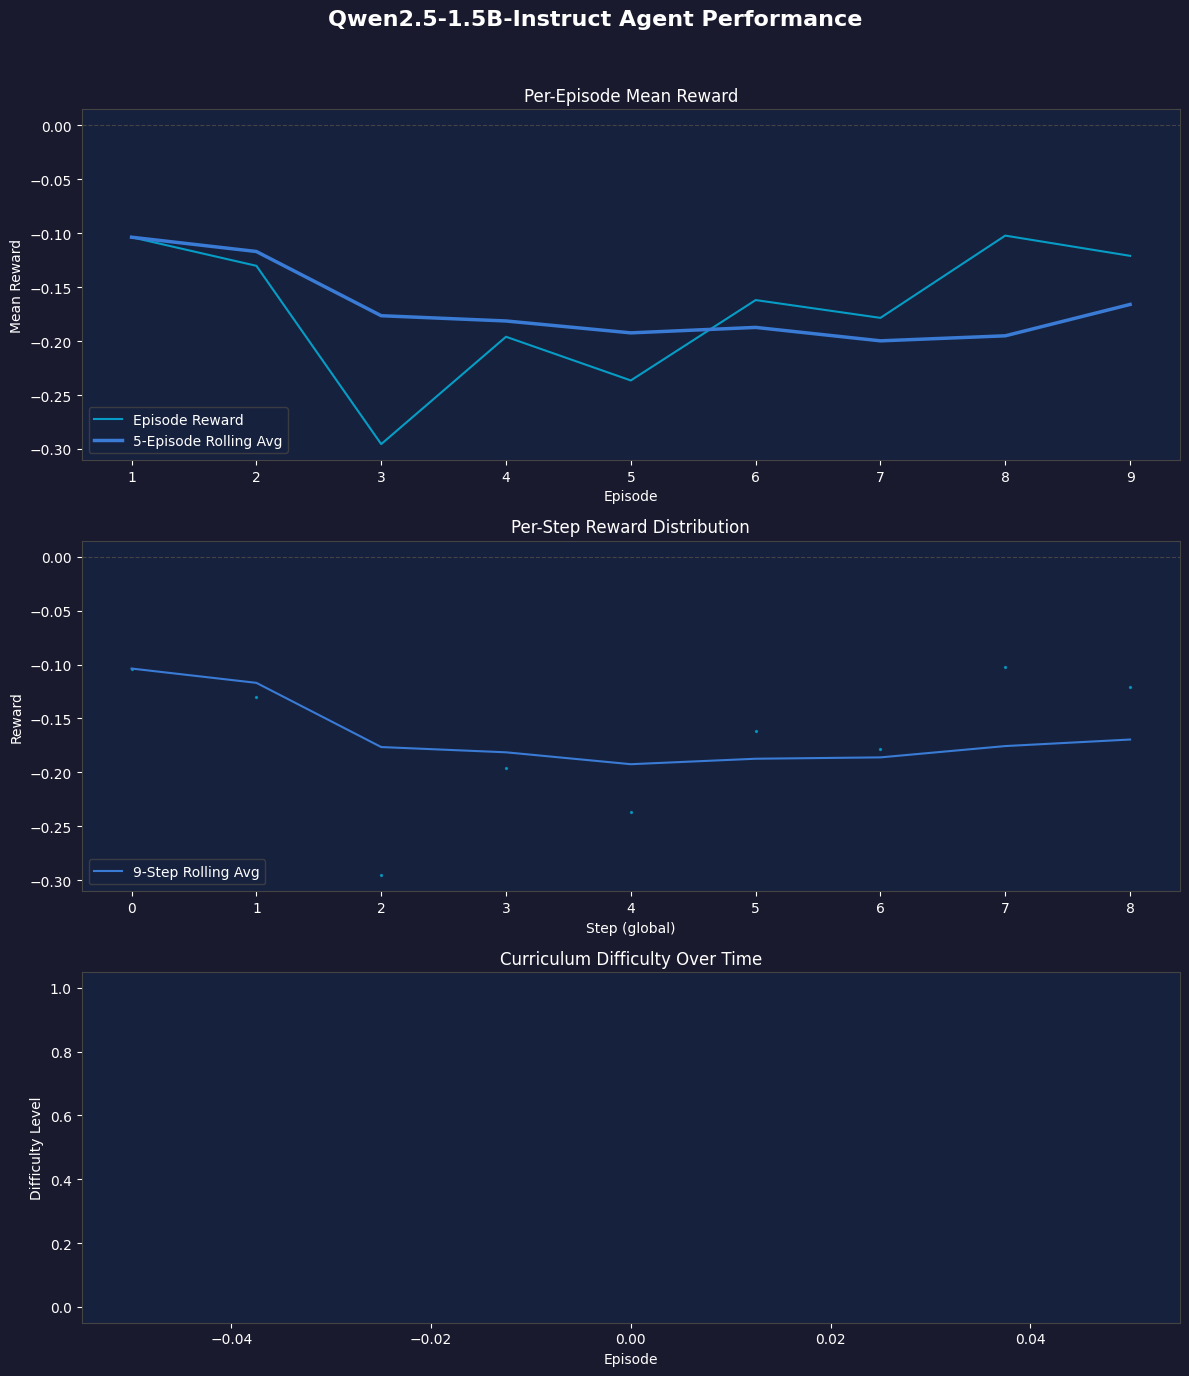

In [33]:
# 5. Plot the Results
import matplotlib.pyplot as plt
import os

def plot_results(episode_rewards, step_rewards, difficulty_trace, title_suffix=""):
    fig, axes = plt.subplots(3, 1, figsize=(12, 14), facecolor="#1a1a2e")
    fig.suptitle(f"Qwen2.5-1.5B-Instruct Agent Performance{title_suffix}", fontsize=16, color="white", fontweight="bold")

    for ax in axes:
        ax.set_facecolor("#16213e")
        ax.tick_params(colors="white")
        ax.xaxis.label.set_color("white")
        ax.yaxis.label.set_color("white")
        ax.title.set_color("white")
        for spine in ax.spines.values():
            spine.set_color("#444")

    # 1. Episode mean reward
    ax1 = axes[0]
    ax1.plot(range(1, len(episode_rewards)+1), episode_rewards, color="#00d2ff", linewidth=1.5, alpha=0.7, label="Episode Reward")
    window = min(5, len(episode_rewards))
    if window > 1:
        rolling = [sum(episode_rewards[max(0,i-window):i+1]) / len(episode_rewards[max(0,i-window):i+1]) for i in range(len(episode_rewards))]
        ax1.plot(range(1, len(rolling)+1), rolling, color="#3a7bd5", linewidth=2.5, label=f"{window}-Episode Rolling Avg")
    ax1.axhline(y=0, color="#444", linestyle="--", linewidth=0.8)
    ax1.set_xlabel("Episode")
    ax1.set_ylabel("Mean Reward")
    ax1.set_title("Per-Episode Mean Reward")
    ax1.legend(facecolor="#16213e", edgecolor="#444", labelcolor="white")

    # 2. Step-level rewards
    ax2 = axes[1]
    ax2.scatter(range(len(step_rewards)), step_rewards, s=2, alpha=0.5, color="#00d2ff")
    step_window = min(20, len(step_rewards))
    if step_window > 1:
        step_rolling = [sum(step_rewards[max(0,i-step_window):i+1]) / len(step_rewards[max(0,i-step_window):i+1]) for i in range(len(step_rewards))]
        ax2.plot(range(len(step_rolling)), step_rolling, color="#3a7bd5", linewidth=1.5, label=f"{step_window}-Step Rolling Avg")
    ax2.axhline(y=0, color="#444", linestyle="--", linewidth=0.8)
    ax2.set_xlabel("Step (global)")
    ax2.set_ylabel("Reward")
    ax2.set_title("Per-Step Reward Distribution")
    ax2.legend(facecolor="#16213e", edgecolor="#444", labelcolor="white")

    # 3. Difficulty trace
    ax3 = axes[2]
    ax3.plot(range(1, len(difficulty_trace)+1), difficulty_trace, color="#b620e0", linewidth=2)
    ax3.set_xlabel("Episode")
    ax3.set_ylabel("Difficulty Level")
    ax3.set_title("Curriculum Difficulty Over Time")
    ax3.set_ylim(-0.05, 1.05)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Extract data from logs and rewards generated in the previous training cell
ep_r = rewards # 'rewards' from the previous cell are the episode rewards
step_r = [x['rewards/gauntlet_reward_fn/mean'] for x in logs if 'rewards/gauntlet_reward_fn/mean' in x] # Assuming this is the step reward
diff_t = [x['rewards/gauntlet_reward_fn/difficulty'] for x in logs if 'rewards/gauntlet_reward_fn/difficulty' in x] # Assuming this is the difficulty trace


if os.path.exists('environment.py'):
    plot_results(ep_r, step_r, diff_t)

In [34]:
# Inspect the keys available in the logs to find the correct difficulty trace key
if logs:
    print("Keys available in the first log entry:")
    for key in logs[0].keys():
        print(f"- {key}")
else:
    print("Logs are empty. Please ensure the training step ran successfully.")

Keys available in the first log entry:
- loss
- grad_norm
- learning_rate
- num_tokens
- completions/mean_length
- completions/min_length
- completions/max_length
- completions/clipped_ratio
- completions/mean_terminated_length
- completions/min_terminated_length
- completions/max_terminated_length
- rewards/gauntlet_reward_fn/mean
- rewards/gauntlet_reward_fn/std
- reward
- reward_std
- frac_reward_zero_std
- completion_length
- kl
- clip_ratio/low_mean
- clip_ratio/low_min
- clip_ratio/high_mean
- clip_ratio/high_max
- clip_ratio/region_mean
- epoch
- step
